# Evaluación de los modelos de regresión

Mismo protocolo que el capítulo 06: de cada uno de los 7 regresores se toma la mejor combinación
por AUC externo medio, se reentrena sobre todo el desarrollo y se evalúa una sola vez en la prueba.
Se reportan las métricas que exige la Sección 5.2 (RMSE, MAE), el AUC-ROC común del proyecto, la
gráfica de ajuste en entrenamiento, validación y prueba, y el análisis de residuos completo (White,
BDS, ACF con Ljung-Box, histograma y normalidad).

Dos referencias sin modelo acompañan a las métricas: **predecir siempre la tasa base** de desarrollo
(el mejor predictor constante en error cuadrático) y **predecir siempre 0** (el mejor constante en
error absoluto, porque la mediana de `TARGET` es 0).

In [1]:
# --- preambulo comun: localiza la raiz del libro y carga el paquete src ------
import os, sys, warnings
from pathlib import Path
RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "_config.yml").is_file() and (p / "src").is_dir())
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))
# los procesos paralelos de joblib (loky) tambien deben encontrar `src`
os.environ["PYTHONPATH"] = str(RAIZ) + os.pathsep + os.environ.get("PYTHONPATH", "")
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="IProgress not found")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from src import config, graficos
config.fijar_semillas()
config.crear_directorios()
graficos.estilo()
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
print(config.resumen())

Raiz del proyecto     : entregable3
Modo prueba           : False
Semilla               : 42
CV anidada            : 5 externos x 3 internos
Evaluaciones/optimiz. : 20
Nucleos               : 11   paralelo interno: True
XGBoost               : device='cuda'
Random Forest         : xgbrf   KNN: torch


In [2]:
from sklearn.metrics import roc_auc_score
from src import experimento as ex, finales as fin, metricas as met, datos, diagnostico as dg
from src.graficos import COLOR_CONJ, PALETA

pliegues, maestra = ex.consolidar()
conj = datos.cargar_traspaso()
finalistas = fin.seleccionar_finalistas(maestra, "regresion")
display(finalistas[["modelo", "optimizador", "m_auc_roc_media", "m_auc_roc_sd", "m_rmse_media",
                    "m_mae_media"]].style.format(precision=4).hide(axis="index"))
tabla_final = fin.evaluar_finalistas(conj, "regresion", finalistas)
R = fin.cargar_finales("regresion")
print(f"Modelos finales disponibles: {len(R)} de 7")

modelo,optimizador,m_auc_roc_media,m_auc_roc_sd,m_rmse_media,m_mae_media
xgboost,bayesiana,0.7695,0.0032,0.2596,0.1366
lasso,aleatoria,0.7554,0.0026,0.2628,0.1448
ridge,bayesiana,0.7549,0.0026,0.2629,0.1451
random_forest,bayesiana,0.7476,0.0035,0.2630,0.1405
arbol,genetica,0.6965,0.0060,0.2667,0.1410
knn,rejilla,0.6887,0.0013,0.2671,0.1416
svr,rejilla,0.6592,0.0034,0.3497,0.3323


  xgboost        ya evaluado
  lasso          ya evaluado
  ridge          ya evaluado
  random_forest  ya evaluado
  arbol          ya evaluado
  knn            ya evaluado
  svr            ya evaluado


Modelos finales disponibles: 7 de 7


## 1. Métricas y pruebas de supuestos en prueba (Cuadro 3 de la guía)

Los residuos se ordenan por la fila original de `application_train` (orden de `SK_ID_CURR`), el único
orden natural disponible: Home Credit no registra la fecha de la solicitud. BDS se calcula por
bloques consecutivos de 5,000 residuos (su coste es cuadrático en n) y sus valores p se combinan con
el método de Fisher. La prueba de White usa su forma especial con (ŷ, ŷ²) como regresores auxiliares.
Los resultados se guardan y no se recalculan.

In [3]:
ruta_diag = config.DIR_RESULTADOS / "diagnostico_residuos_regresion.csv"
diag_prev = pd.read_csv(ruta_diag).set_index("Modelo") if ruta_diag.is_file() else pd.DataFrame()
y_te = conj.y_te.to_numpy().astype(float)
tasa = float(conj.y_dev.mean())
filas = []
referencias = {"constante: tasa base": np.full_like(y_te, tasa), "constante: 0": np.zeros_like(y_te)}
for m, d in R.items():
    o = np.argsort(d["fila"])
    y, yh = d["y"][o].astype(float), d["s"][o]
    mt = met.metricas_regresion(y, yh)
    fila = {"Modelo": m, "RMSE": mt["rmse"], "MAE": mt["mae"], "R2": mt["r2"], "AUC": mt["auc_roc"]}
    if m in diag_prev.index:
        fila.update(diag_prev.loc[m, [c for c in diag_prev.columns if c.startswith(("p_", "asim", "curt"))]].to_dict())
    else:
        try:
            fila.update(dg.diagnostico_completo(y, yh))
        except Exception as e:
            print(f"{m}: diagnóstico falló ({e})")
    filas.append(fila)
for nombre, yh in referencias.items():
    mt = met.metricas_regresion(y_te, yh)
    filas.append({"Modelo": nombre, "RMSE": mt["rmse"], "MAE": mt["mae"], "R2": mt["r2"],
                  "AUC": mt["auc_roc"]})
tabla_reg = pd.DataFrame(filas)
tabla_reg[tabla_reg["Modelo"].isin(R)].to_csv(ruta_diag, index=False)
cols = ["Modelo", "RMSE", "MAE", "R2", "AUC", "p_white", "p_bds_fisher", "p_ljung_box_10",
        "p_jarque_bera"]
display(tabla_reg[[c for c in cols if c in tabla_reg]].sort_values("RMSE")
        .style.format(precision=4, na_rep="-").hide(axis="index"))

Modelo,RMSE,MAE,R2,AUC,p_white,p_bds_fisher,p_ljung_box_10,p_jarque_bera
xgboost,0.2585,0.1359,0.0996,0.7737,0.0000,0.1472,0.5233,0.0000
random_forest,0.2622,0.1397,0.0736,0.7546,0.0000,0.1607,0.4413,0.0000
lasso,0.2624,0.1441,0.0723,0.7604,0.0000,0.1730,0.5560,0.0000
ridge,0.2625,0.1444,0.0718,0.7594,0.0000,0.1740,0.5850,0.0000
arbol,0.2661,0.1401,0.0456,0.7017,0.0000,0.1602,0.6755,0.0000
knn,0.2668,0.1412,0.0405,0.6975,0.0000,0.1602,0.2253,0.0000
constante: tasa base,0.2724,0.1484,-0.0000,0.5000,-,-,-,-
constante: 0,0.2841,0.0807,-0.0878,0.5000,-,-,-,-
svr,0.3497,0.3323,-0.6478,0.6658,0.0000,0.1602,0.2504,0.0000


**Lectura.** **(1) Orden por RMSE frente a orden por AUC.** Coinciden en los extremos —XGBoost es
el mejor (RMSE 0.2585, AUC 0.7737) y SVR el peor— pero no en el medio: Random Forest tiene mejor RMSE
que Lasso y Ridge (0.2622 frente a 0.2624-0.2625) con un AUC 0.005-0.006 menor. El RMSE de un
objetivo 0/1 es la raíz del Brier y mezcla discriminación con calibración; los modelos lineales de
probabilidad ordenan mejor, pero producen predicciones fuera de [0, 1] (sección 3) que el error
cuadrático castiga.

**(2) MAE.** Ningún modelo supera a "predecir siempre 0" (MAE 0.0807); el mejor, XGBoost, tiene
0.1359. El MAE se minimiza con la mediana condicional, que es 0 para casi todos los solicitantes, de
modo que premia no discriminar: con un objetivo binario desbalanceado no sirve para elegir modelo.

**(3) R².** El del mejor modelo es 0.10: explica una décima parte de la varianza p(1 − p) = 0.074 del
objetivo. Es lo esperable para un evento del 8 % con predictores débiles y no contradice un AUC de
0.77: ordenar bien no exige alejar mucho las probabilidades de la tasa base. SVR tiene R² de −0.65 y
RMSE de 0.350, peor que la constante igual a la tasa base (0.272): sus predicciones son prácticamente
constantes y, aun así, conservan algo de orden (AUC 0.666).

**(4) Supuestos.** White y Jarque-Bera rechazan en todos los modelos (p < 0.0001), como se anticipó:
el residuo de un objetivo 0/1 solo toma dos valores por observación y su varianza p(1 − p) depende de
ŷ. Las pruebas informativas no rechazan: BDS (p entre 0.15 y 0.17) y Ljung-Box (p entre 0.23 y 0.68)
no encuentran dependencia en el orden de `SK_ID_CURR`.

## 2. Ajuste en entrenamiento, validación y prueba (Sección 5.2.1)

Para el mejor regresor según el AUC de validación cruzada se reajusta el modelo con la partición de
la línea base (64 % entrenamiento) y se predice sobre entrenamiento, validación (16 %) y prueba
(20 %). Como el objetivo es 0/1, una serie de puntos individuales no se puede leer; se grafican, en
el orden de `SK_ID_CURR`, la **media móvil** de `TARGET` observado y de la predicción (ventana de
2,000 solicitudes), y la calibración por deciles en cada conjunto.

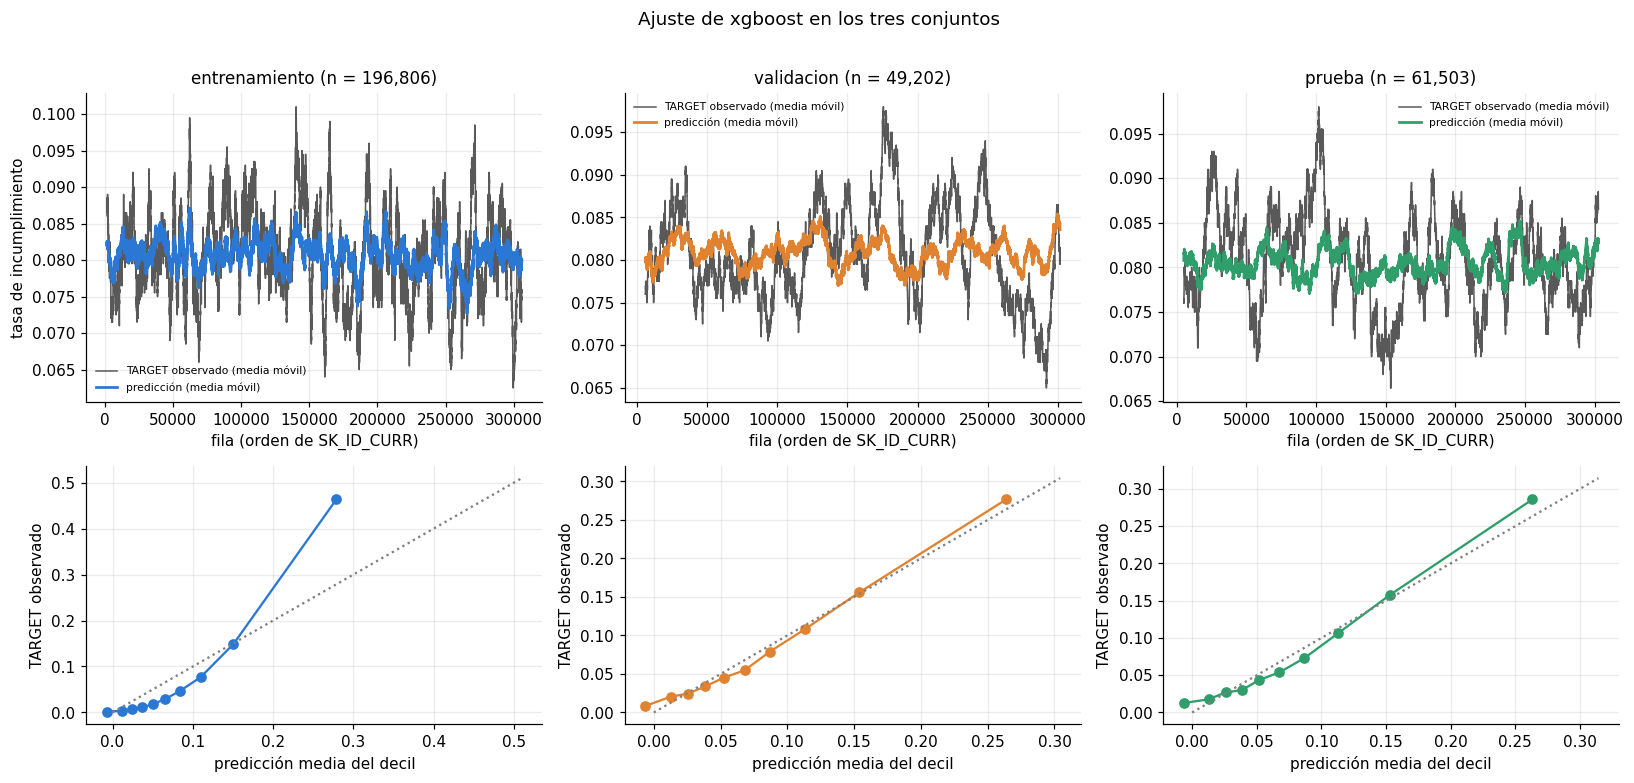

conjunto,rmse,mae,r2,auc_roc,auc_pr
entrenamiento,0.2385,0.1252,0.2337,0.8899,0.5475
validacion,0.2599,0.1369,0.0898,0.7688,0.2478
prueba,0.2587,0.1360,0.0979,0.7727,0.2641


In [4]:
mejor_reg = finalistas.iloc[0]
reg_m = R[mejor_reg["modelo"]]["registro"] if mejor_reg["modelo"] in R else None
if reg_m is not None:
    tres = fin.ajuste_tres_conjuntos(conj, "regresion", reg_m["modelo"], reg_m["balanceo"], reg_m["params"])
    VENT = 200 if config.MODO_PRUEBA else 2000
    fig, axes = plt.subplots(2, 3, figsize=(15, 7), gridspec_kw={"height_ratios": [1.2, 1]})
    filas = []
    for j, cjto in enumerate(["entrenamiento", "validacion", "prueba"]):
        g = tres[tres["conjunto"] == cjto].sort_values("fila")
        ax = axes[0, j]
        ax.plot(g["fila"], g["y"].rolling(VENT, center=True).mean(), color="0.35", lw=1,
                label="TARGET observado (media móvil)")
        ax.plot(g["fila"], g["y_hat"].rolling(VENT, center=True).mean(), color=COLOR_CONJ[cjto],
                lw=1.8, label="predicción (media móvil)")
        ax.set_title(f"{cjto} (n = {len(g):,})"); ax.set_xlabel("fila (orden de SK_ID_CURR)")
        ax.legend(fontsize=7)
        dec = pd.qcut(g["y_hat"].rank(method="first"), 10, labels=False)
        c = g.groupby(dec).agg(pred=("y_hat", "mean"), obs=("y", "mean"))
        axes[1, j].plot(c["pred"], c["obs"], marker="o", color=COLOR_CONJ[cjto])
        lim = max(c["pred"].max(), c["obs"].max()) * 1.1
        axes[1, j].plot([0, lim], [0, lim], ls=":", color="0.5")
        axes[1, j].set_xlabel("predicción media del decil"); axes[1, j].set_ylabel("TARGET observado")
        mt = met.metricas_regresion(g["y"], g["y_hat"])
        filas.append({"conjunto": cjto, **mt})
    axes[0, 0].set_ylabel("tasa de incumplimiento")
    fig.suptitle(f"Ajuste de {reg_m['modelo']} en los tres conjuntos", y=1.01)
    fig.tight_layout()
    graficos.guardar(fig, "07_ajuste_tres_conjuntos")
    plt.show()
    display(pd.DataFrame(filas).style.format(precision=4).hide(axis="index"))

La misma representación para los siete regresores (Sección 5.2.1: para cada modelo), en forma
compacta: en cada fila un modelo y en cada columna un conjunto, con la media móvil de `TARGET`
observado (gris) y de la predicción. La tabla resume el RMSE y el AUC de cada modelo en los tres
conjuntos. Cada modelo se ajusta una sola vez con la partición de la línea base y el resultado se
guarda en disco.

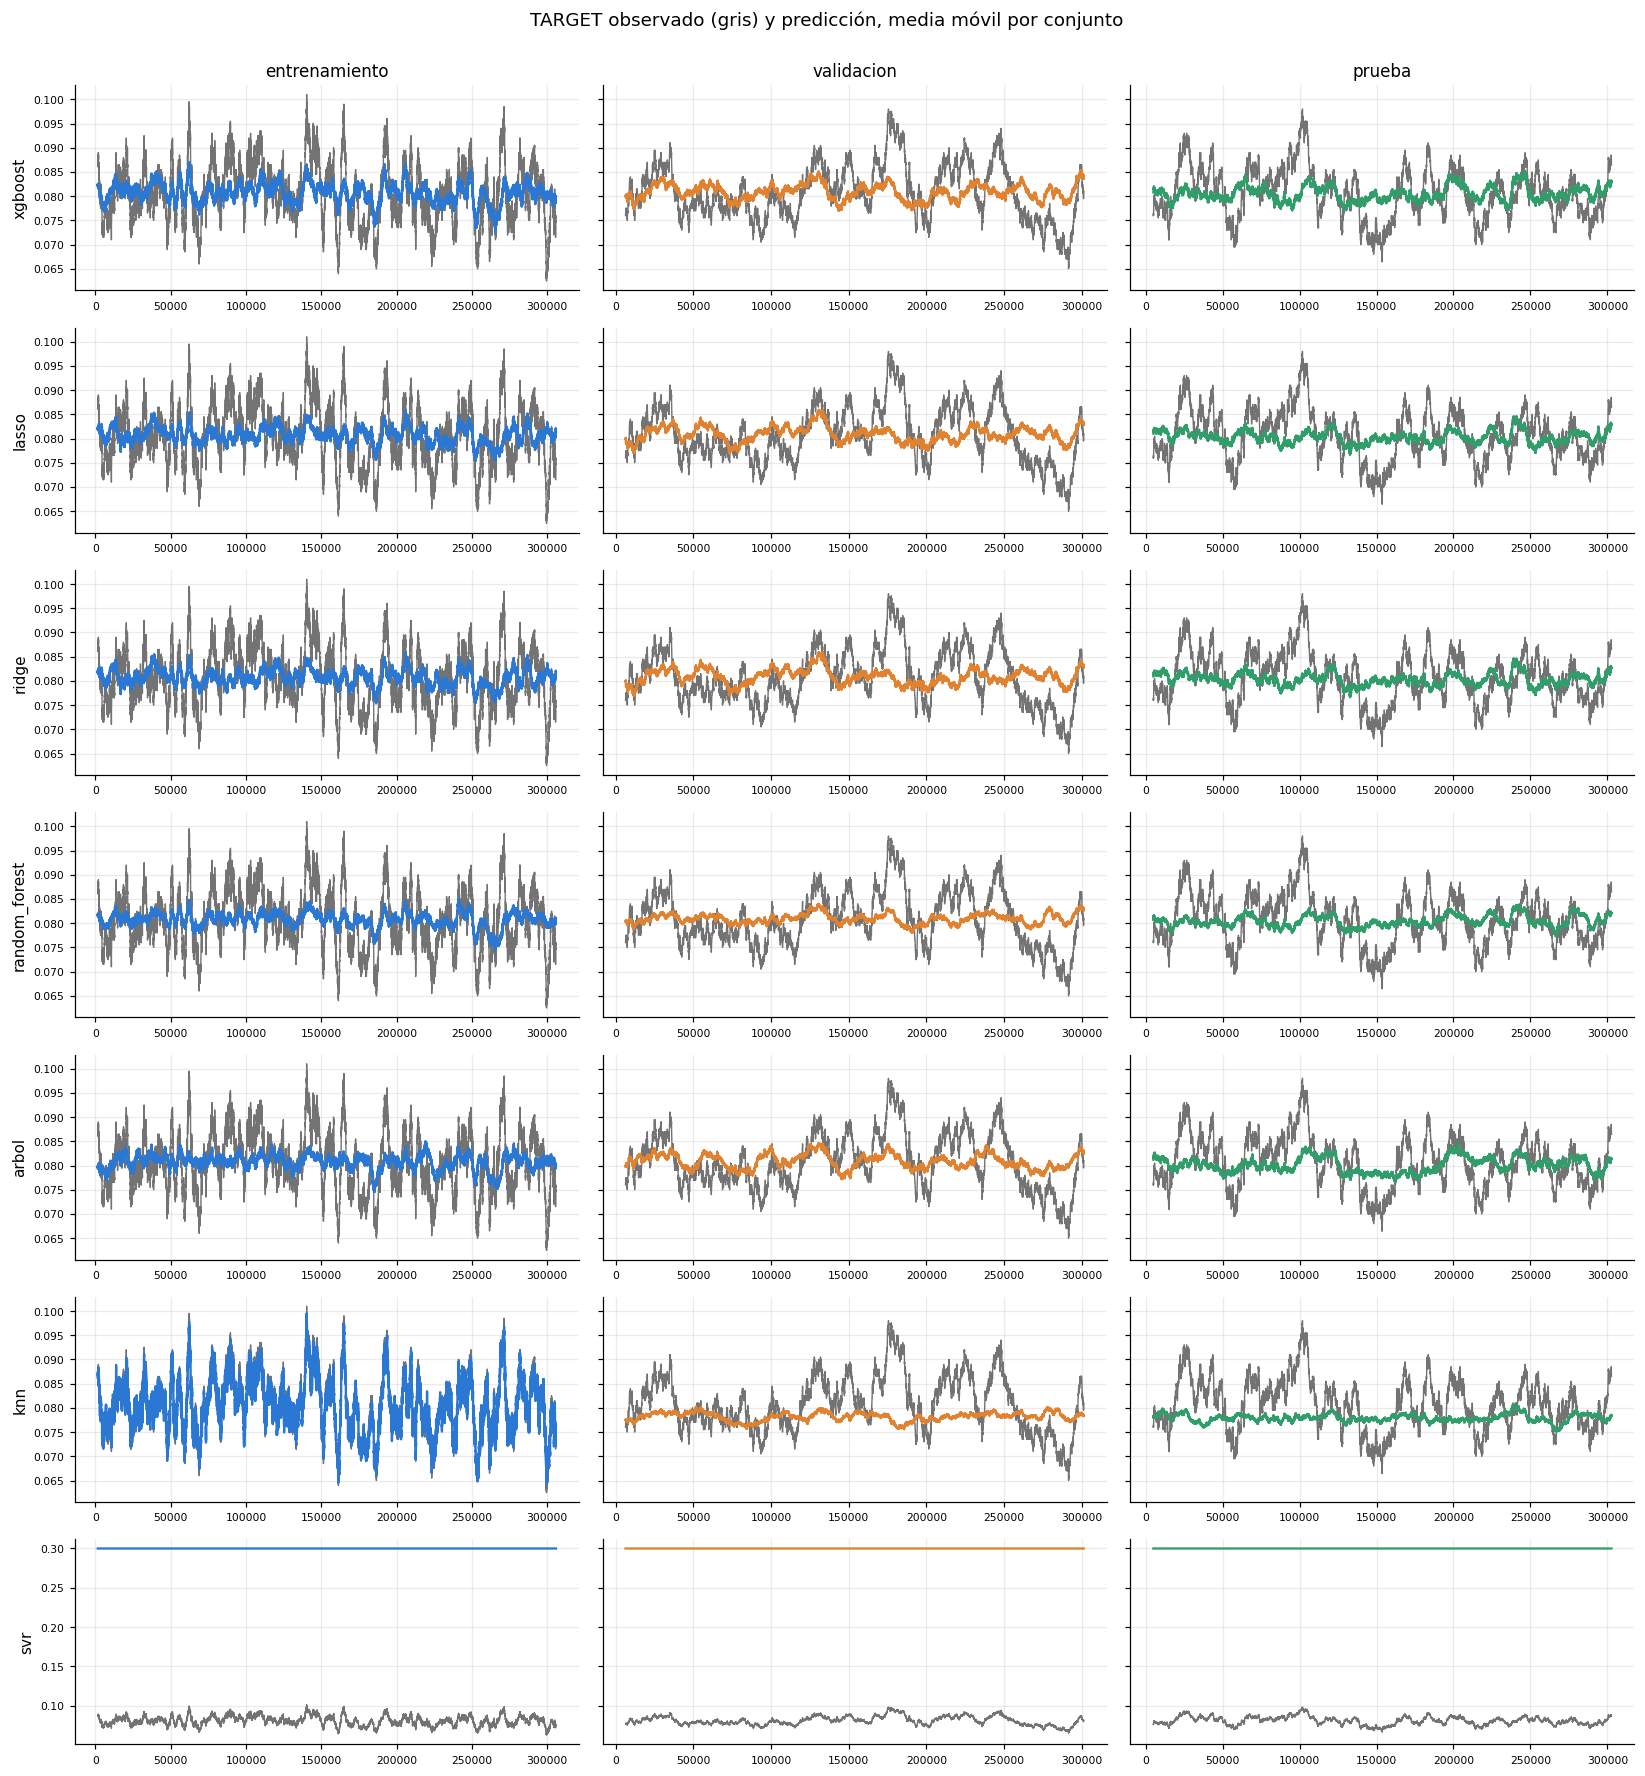

In [5]:
VENT = 200 if config.MODO_PRUEBA else 2000
modelos_r = [m for m in finalistas["modelo"] if m in R]
fig, axes = plt.subplots(len(modelos_r), 3, figsize=(15, 2.3 * len(modelos_r)), sharey="row",
                         squeeze=False)
filas_todos = []
for i, m in enumerate(modelos_r):
    rg = R[m]["registro"]
    tr = fin.ajuste_tres_conjuntos(conj, "regresion", rg["modelo"], rg["balanceo"], rg["params"])
    for j, cjto in enumerate(["entrenamiento", "validacion", "prueba"]):
        g = tr[tr["conjunto"] == cjto].sort_values("fila")
        ax = axes[i, j]
        ax.plot(g["fila"], g["y"].rolling(VENT, center=True).mean(), color="0.45", lw=0.9)
        ax.plot(g["fila"], g["y_hat"].rolling(VENT, center=True).mean(), color=COLOR_CONJ[cjto], lw=1.5)
        if i == 0:
            ax.set_title(cjto)
        if j == 0:
            ax.set_ylabel(m)
        ax.tick_params(labelsize=7)
        filas_todos.append({"modelo": m, "conjunto": cjto, **met.metricas_regresion(g["y"], g["y_hat"])})
fig.suptitle("TARGET observado (gris) y predicción, media móvil por conjunto", y=1.0)
fig.tight_layout()
graficos.guardar(fig, "07_ajuste_tres_conjuntos_todos")
plt.show()
ajuste_todos = pd.DataFrame(filas_todos)
display(ajuste_todos.pivot_table(index="modelo", columns="conjunto", values=["rmse", "auc_roc"])
        .reindex(modelos_r).style.format(precision=4))

**Lectura.** Los siete regresores muestran tres comportamientos. **XGBoost, Random Forest y KNN
memorizan el entrenamiento**: su AUC de entrenamiento (0.890, 0.913 y 1.000) está muy por encima del
de validación (0.769, 0.750 y 0.690); en KNN el AUC de 1.000 es esperable, porque con ponderación por
distancia cada observación de entrenamiento es su propio vecino más cercano. **Los modelos lineales y el
árbol apenas se separan** (Lasso 0.762 en entrenamiento frente a 0.754 en validación; Ridge 0.763 frente a
0.754; árbol 0.736 frente a 0.695). **SVR predice casi una constante** en los tres conjuntos, con el mismo
RMSE (0.350) y un AUC de 0.66 en todos ellos. En las gráficas se ve lo mismo: la media móvil de la
predicción de XGBoost, Random Forest y KNN sigue de cerca las oscilaciones de `TARGET` en
entrenamiento y mucho menos en validación y prueba, mientras que la de SVR es una línea plana.

Lo importante para la evaluación es que en los siete modelos el AUC de validación y el de prueba
coinciden (diferencias de 0.004 a 0.008): el sobreajuste al entrenamiento no contamina la
estimación del desempeño fuera de la muestra, y el orden de los modelos es el mismo en validación y
en prueba.

## 3. Análisis de residuos (Sección 5.2.2)

Para cada regresor: residuos frente a valores ajustados (con la media por bins, que revela patrones
sistemáticos), función de autocorrelación con el valor p de Ljung-Box, e histograma de residuos.

Qué esperar con un objetivo 0/1. El residuo de una observación es −ŷ si y = 0 o 1 − ŷ si y = 1: en el
gráfico de residuos aparecen **dos bandas** paralelas de pendiente −1, y su varianza condicional es
p(1−p), máxima cerca de 0.5; de ahí el rechazo de White. El histograma es **bimodal y asimétrico**
(una masa grande cerca de −0.08 y una pequeña cerca de +0.9): Jarque-Bera rechaza la normalidad por
construcción. Lo que sí informa sobre la especificación es la **media** de los residuos por bin de ŷ:
si se aleja de cero, el modelo sobre- o sub-estima el riesgo en esa zona (descalibración).

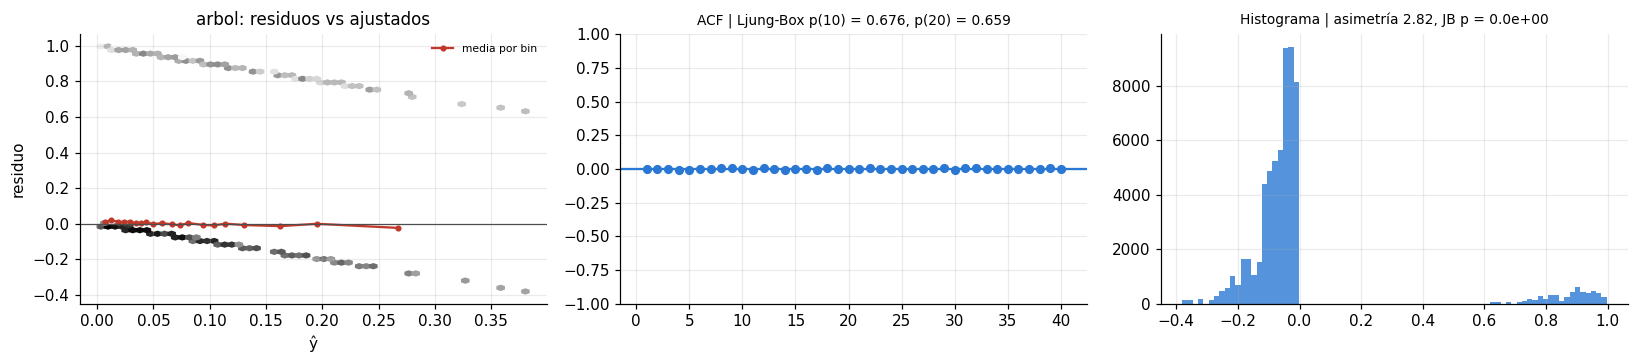

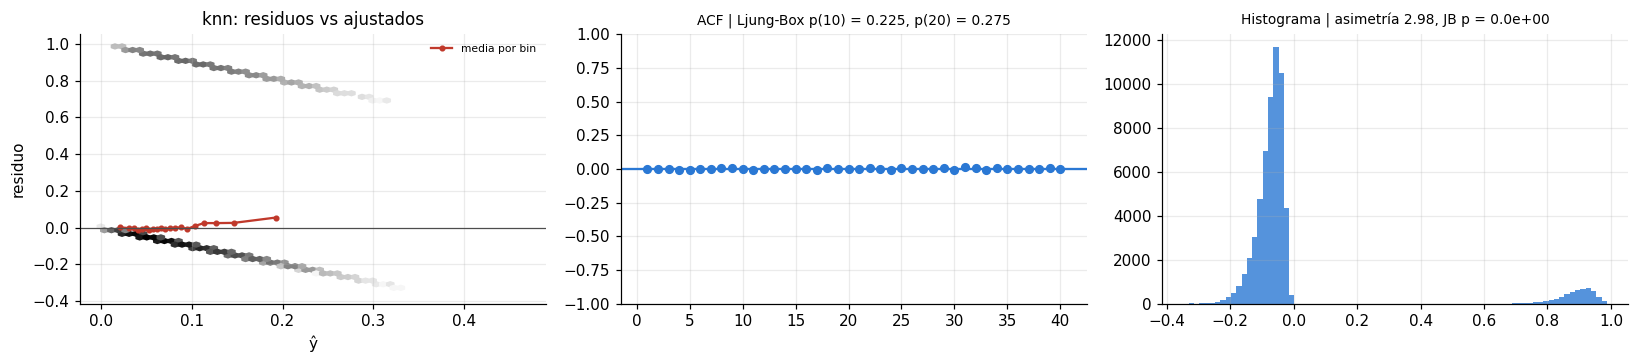

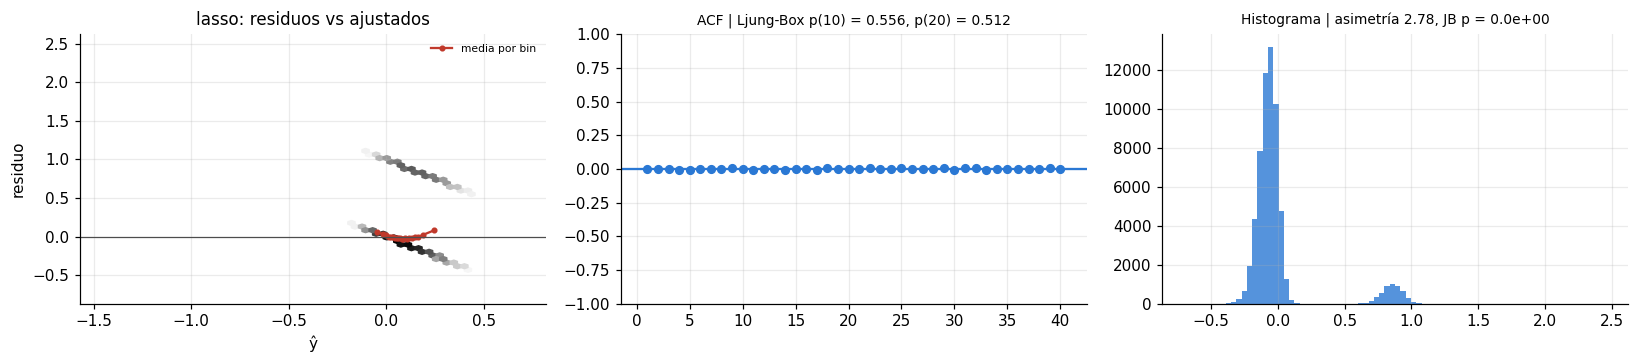

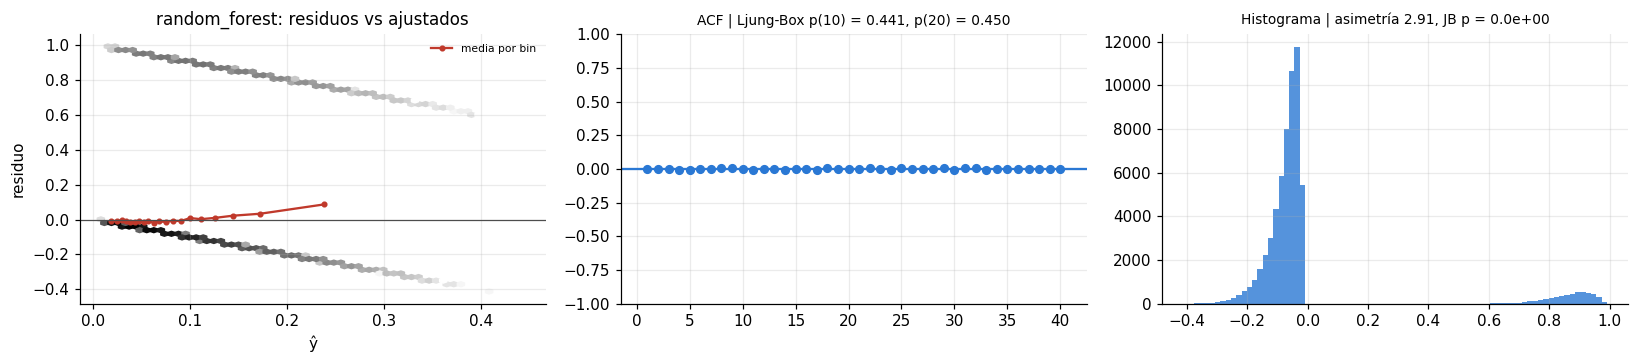

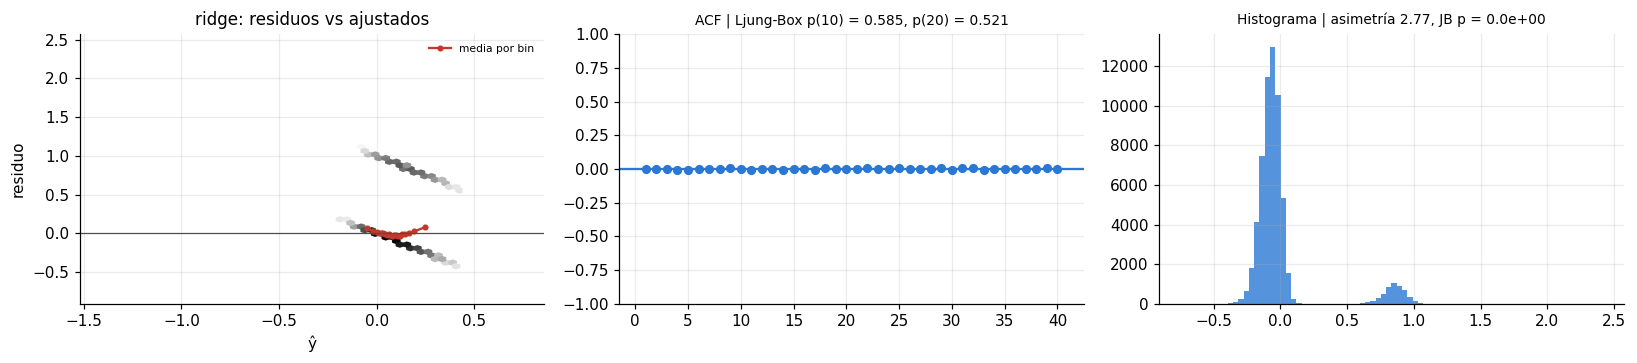

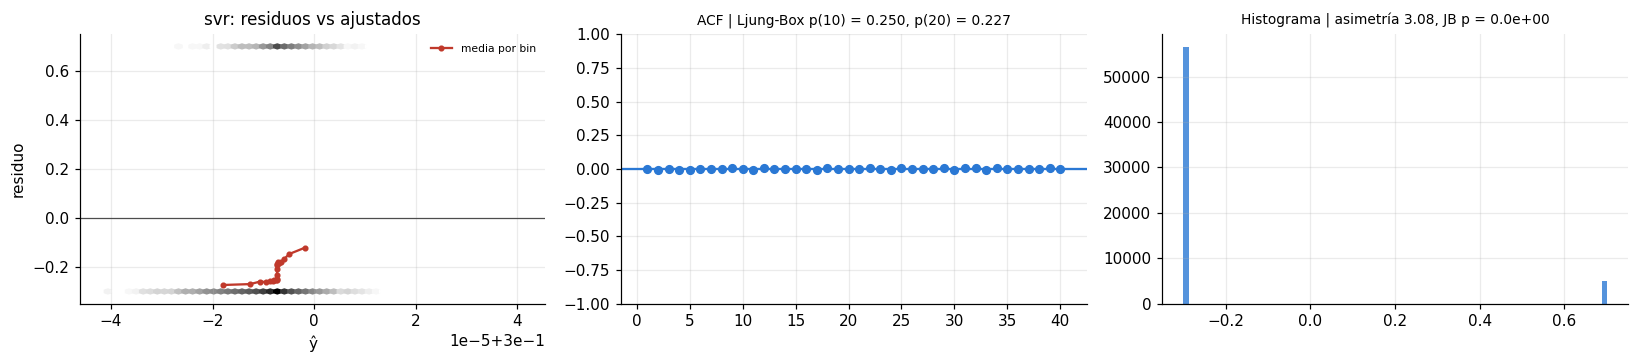

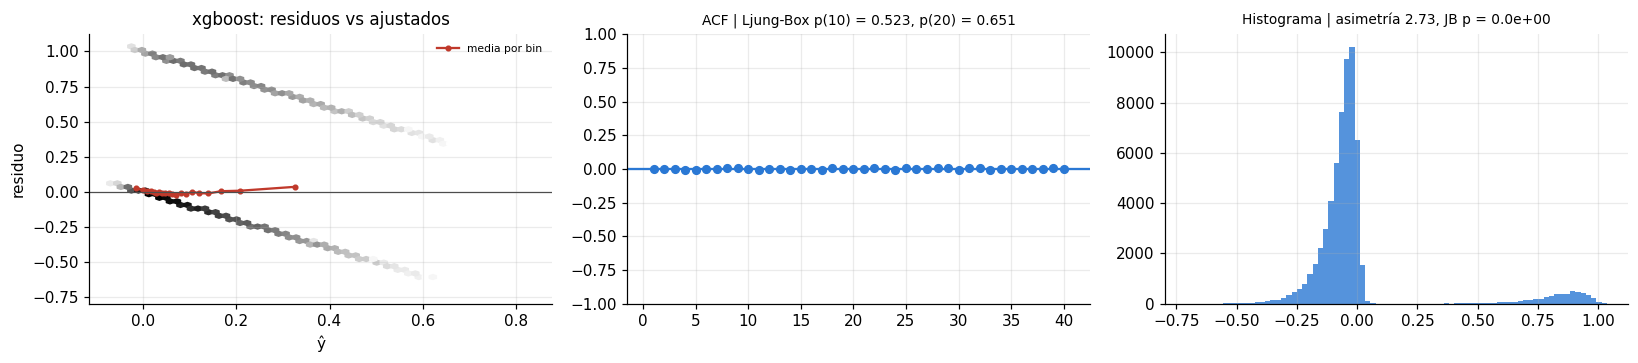

In [6]:
from statsmodels.graphics.tsaplots import plot_acf
for m, d in R.items():
    o = np.argsort(d["fila"])
    y, yh = d["y"][o].astype(float), d["s"][o]
    e = y - yh
    fig, ax = plt.subplots(1, 3, figsize=(15, 3.4))
    ax[0].hexbin(yh, e, gridsize=60, bins="log", cmap="Greys", mincnt=1)
    b = pd.qcut(pd.Series(yh).rank(method="first"), 20, labels=False)
    mb = pd.DataFrame({"yh": yh, "e": e}).groupby(b).mean()
    ax[0].plot(mb["yh"], mb["e"], color="#c0392b", marker="o", ms=3, lw=1.5, label="media por bin")
    ax[0].axhline(0, color="0.3", lw=0.8)
    ax[0].set_xlabel("ŷ"); ax[0].set_ylabel("residuo"); ax[0].legend(fontsize=7)
    ax[0].set_title(f"{m}: residuos vs ajustados")
    plot_acf(e, lags=40, ax=ax[1], alpha=0.05, zero=False)
    lb = dg.prueba_ljung_box(e)
    ax[1].set_title(f"ACF | Ljung-Box p(10) = {lb['lb_pvalue'].iloc[0]:.3f}, "
                    f"p(20) = {lb['lb_pvalue'].iloc[-1]:.3f}", fontsize=9)
    ax[2].hist(e, bins=80, color="#2a78d4", alpha=0.8)
    nrm = dg.pruebas_normalidad(e)
    ax[2].set_title(f"Histograma | asimetría {nrm['asimetria']:.2f}, JB p = {nrm['p_jb']:.1e}",
                    fontsize=9)
    fig.tight_layout()
    graficos.guardar(fig, f"07_residuos_{m}")
    plt.show()

**Lectura.** Ninguna prueba detecta dependencia serial: Ljung-Box da p entre 0.23 y 0.68 con 10 y
20 rezagos y la autocorrelación de los siete modelos queda pegada a cero, lo esperable porque
`SK_ID_CURR` es un identificador sin contenido temporal. La media de los residuos por bin de ŷ, que es
la forma práctica de comprobar la calibración de un regresor, está cerca de cero en la mayor parte
del rango en el árbol, XGBoost, KNN y Random Forest; en los tres últimos se vuelve positiva en los
bins más altos (hasta ≈ +0.04 en XGBoost, +0.05 en KNN y +0.09 en Random Forest), es decir, estos
modelos subestiman el riesgo de los solicitantes más riesgosos. En Lasso y Ridge la curva tiene forma
de U, con residuos positivos en los dos extremos e incluidas predicciones negativas: es el límite del
modelo lineal de probabilidad, que no puede curvarse hacia 0 y 1 como un logit. SVR es el caso
extremo: todas sus predicciones caen en una franja de ±4·10⁻⁵ alrededor de 0.30, de modo que el
gráfico de residuos se reduce a dos bandas horizontales (−0.30 para los cumplidores y +0.70 para los
incumplidores) y la media por bin es negativa en todo el rango. El único modelo con un problema
estructural es SVR.